In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_01/cvMeasure"
os.makedirs(figureroot, exist_ok=True)

In [3]:
load_dir = "../system_01/results/cvMeasure/"
load_str = datetime.datetime(2024, 3, 13)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [23]:
iE = -0.1 / params['gamma'] - params['i_e2']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

sMin = 2.5; sMax = 16.5; sSteps = 20
sVals = sMin + np.arange(0, sSteps) / (sSteps-1) * (sMax - sMin)

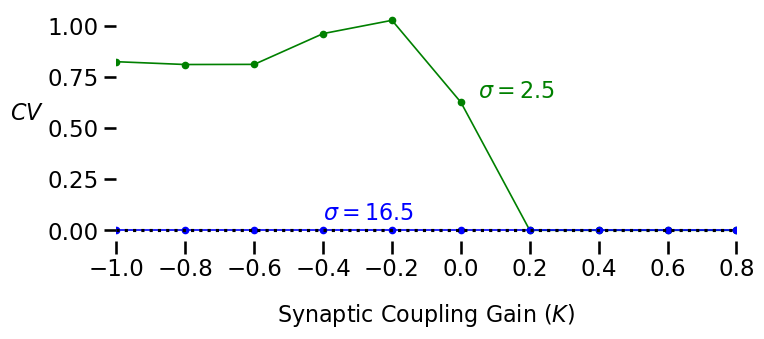

In [27]:
for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue
    plt.figure(figsize=(8, 3))
    cv_results = pickle.load(open(path_, 'rb'))
    
    lowHetCV = abs(cv_results[:, 0])
    HighHetCV = abs(cv_results[:, -1])

    plt.plot(kVals, lowHetCV, 'g.-', linewidth=1.2); plt.text(0.05, 0.65, r"$\sigma=$2.5", color='g', fontsize=16)
    plt.plot(kVals, HighHetCV, 'b.-', linewidth=1.2); plt.text(-0.4, 0.05, r"$\sigma=$"+f"{sVals[-1]:.1f}", color='b', fontsize=16)
    plt.axhline(y=0, color = 'k', linestyle=':')
    plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
    plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
    plt.xlim(kMin, max(kVals))
    plt.xticks(kVals)
    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)
    plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_K.png"), dpi=300, bbox_inches='tight')
        

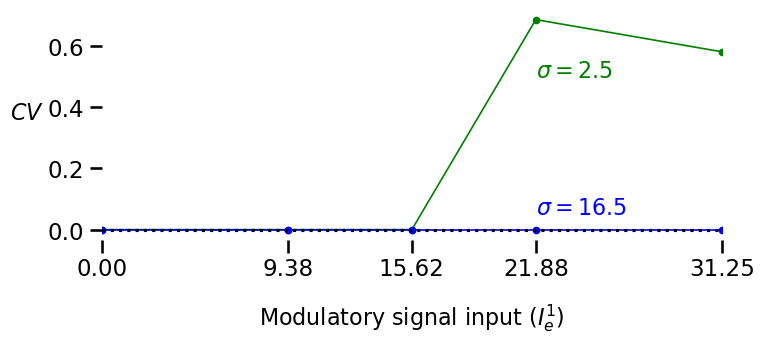

In [6]:
lowHetCV = {}
HighHetCV = {}

Kind = 8
for path_ in file_paths:    
    Basename = os.path.basename(path_).split('mV.pkl')[0]
    iE = float(Basename.split('_I_')[-1]) - params['i_e2']

    cv_results = pickle.load(open(path_, 'rb'))

    lowHetCV[iE] = abs(cv_results[Kind, 0])
    HighHetCV[iE] = abs(cv_results[Kind, -1])

iEvals = np.array(list(lowHetCV.keys()))
iEsort = np.argsort(iEvals)
lowCV = np.array(list(lowHetCV.values()))
highCV = np.array(list(HighHetCV.values()))

lowCV = lowCV[iEsort]
highCV = highCV[iEsort]
iEvals = iEvals[iEsort]

plt.figure(figsize=(8, 3))
plt.plot(iEvals, lowCV, 'g.-', linewidth=1.2); plt.text(21.88, 0.5, r"$\sigma=$2.5", color='g', fontsize=16)
plt.plot(iEvals, highCV, 'b.-', linewidth=1.2); plt.text(21.88, 0.05, r"$\sigma=$16.5", color='b', fontsize=16)
plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$CV$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.xticks(iEvals)
plt.xlim(min(iEvals), max(iEvals))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_Imod.png"), dpi=300, bbox_inches='tight')

#### State transition boundary detection

In [7]:
# setting the variables
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

sMin = 2.5; sMax = 16.5; sSteps = 20
sVals = sMin + np.arange(0, sSteps) / (sSteps-1) * (sMax - sMin)

In [8]:
save_str = datetime.datetime(2024, 3, 13)
results_dict = os.path.join('../system_01/results/cvMeasure/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, "*.pkl"))
num_files = len(file_paths)
print(f"Number of files: {num_files}")

Number of files: 5


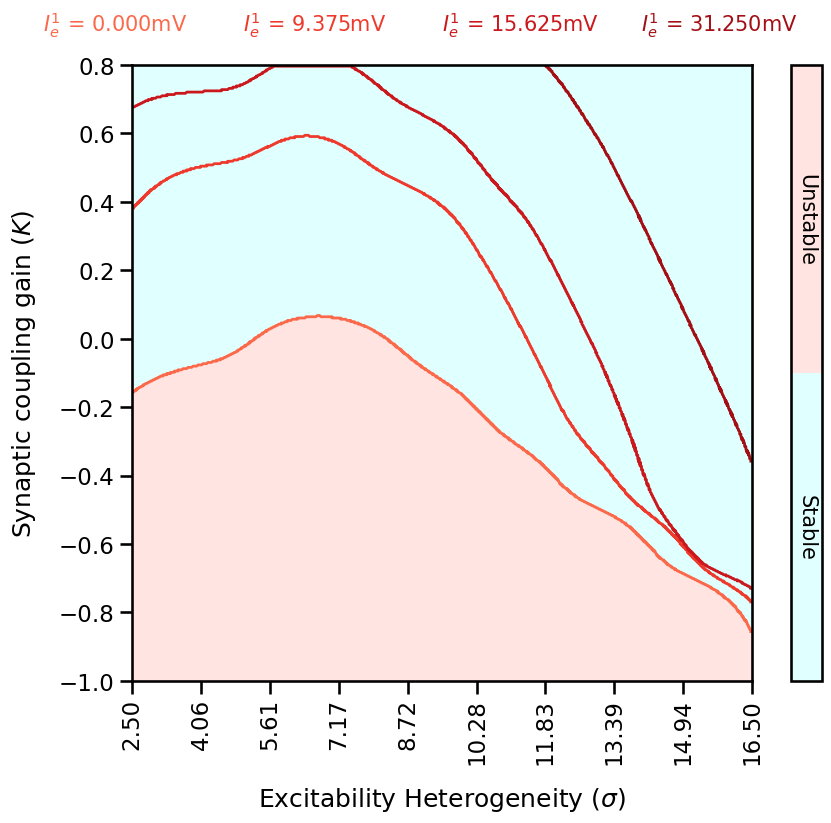

In [9]:
_I = []

for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('mV.pkl')[0]
    I = float(basename.split('_I_')[-1])
    _I.append(I)

_I = np.array(_I)

_Isort = np.argsort(_I)
_I = _I[_Isort]
file_paths = np.array(file_paths)[_Isort]

colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(_I))))

plt.figure(figsize=(10,8))
counter = 0
for nf, path in enumerate(file_paths):
    if nf == 3:
        continue
    basename = os.path.basename(path).split('.pkl')[0]
    color = next(colorIter)

    cv_results = pickle.load(open(path, 'rb'))
    cv_results = abs(cv_results)

    k_arr, sig_arr, response_map = cv_upsample(
                                                orig_response=cv_results, 
                                                eval_arrx=sVals, 
                                                eval_arry=kVals, 
                                                y_min = kMin, y_max = max(kVals), 
                                                x_min = sMin, x_max = max(sVals), 
                                                sigma_x = 25, sigma_y = 25,  
                                                resolution = 500
                                                )
    thresh_map = deepcopy(response_map)
    thresh_map[thresh_map > 0.01] = 1
    thresh_map[thresh_map <= 0.01] = 0

    edge_boundary, sig_edges, k_edges = boundary_detection(thresh_map, k_arr, sig_arr)

    if edge_boundary is None:
        continue

    plot_x = np.linspace(min(sig_edges), max(sig_edges), 1000)
    plot_y = edge_boundary(plot_x)

    plt.plot(sig_edges, k_edges, linewidth=2.0, c = color, label = r"$I^1_e$ = " + f"{_I[nf] - params['i_e2']:.3f}mV")
    plt.text(counter * 4.5 + 0.5, 0.9, r"$I^1_e$ = " + f"{_I[nf] - params['i_e2']:.3f}mV", color=color, fontsize=15)
    counter += 1

    if nf == 0:
        heatmap = plt.pcolormesh(sig_arr, k_arr, thresh_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
        cbar = plt.colorbar(heatmap)

        cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0.5, .75 , r"Unstable", rotation=270, ha='center', va='center', fontsize=15)
        cbar.ax.text(0.5, 0.25 , r"Stable", rotation=270, ha='center', va='center', fontsize=15)

plt.xlabel(r"Excitability Heterogeneity $(\sigma)$", labelpad=15); plt.ylabel(r"Synaptic coupling gain $(K)$", labelpad=15)
plt.xticks(np.linspace(sMin, max(sVals), 10), rotation = 90); plt.yticks(np.linspace(kMin, max(kVals), 10))
plt.xlim(sMin, max(sVals)); plt.ylim(kMin, max(kVals))
plt.savefig(os.path.join(figureroot, "boundarydetection_modulation.png"), dpi = 300, bbox_inches='tight')
plt.show()